In [1]:
# ==========================================
# TASK 9 - PART 1
# Import Libraries & Load Dataset
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Excel File Load
df = pd.read_excel("/content/Task9_ARPU_Cohort_Sample_Dataset.xlsx")

print("="*50)
print("DATA LOADED SUCCESSFULLY")
print("="*50)

# First 5 Rows
print("\nFirst 5 Rows")
display(df.head())

# Dataset Information
print("\nDataset Information")
df.info()

# Shape
print("\nRows and Columns")
print(df.shape)

# Column Names
print("\nColumn Names")
print(df.columns)

# Missing Values
print("\nMissing Values")
print(df.isnull().sum())

# Duplicate Records
print("\nDuplicate Records")
print(df.duplicated().sum())

# Statistical Summary
print("\nStatistical Summary")
display(df.describe(include='all'))

DATA LOADED SUCCESSFULLY

First 5 Rows


,Payment_ID,User_ID,Signup_Date,Payment_Date,Cohort_Month,Plan,Amount,Payment_Status,Country
0,PAY0001,USR104,2025-02-20,2025-03-12,2025-02,Premium,299,Success,UK
1,PAY0002,USR118,2025-06-07,2025-07-16,2025-06,Standard,199,Success,USA
2,PAY0003,USR065,2025-03-23,2025-03-31,2025-03,Standard,299,Success,USA
3,PAY0004,USR099,2025-05-07,2025-06-03,2025-05,Basic,199,Success,India
4,PAY0005,USR144,2025-06-20,2025-08-05,2025-06,Standard,299,Success,UAE



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Payment_ID      500 non-null    object
 1   User_ID         500 non-null    object
 2   Signup_Date     500 non-null    object
 3   Payment_Date    500 non-null    object
 4   Cohort_Month    500 non-null    object
 5   Plan            500 non-null    object
 6   Amount          500 non-null    int64 
 7   Payment_Status  500 non-null    object
 8   Country         500 non-null    object
dtypes: int64(1), object(8)
memory usage: 35.3+ KB

Rows and Columns
(500, 9)

Column Names
Index(['Payment_ID', 'User_ID', 'Signup_Date', 'Payment_Date', 'Cohort_Month',
       'Plan', 'Amount', 'Payment_Status', 'Country'],
      dtype='object')

Missing Values
Payment_ID        0
User_ID           0
Signup_Date       0
Payment_Date      0
Cohort_Month      0
Plan              0
Amount 

,Payment_ID,User_ID,Signup_Date,Payment_Date,Cohort_Month,Plan,Amount,Payment_Status,Country
count,500,500,500,500,500,500,500.000000,500,500
unique,500,174,252,254,10,3,NaN,2,5
top,PAY0500,USR036,2025-09-26,2025-03-27,2025-08,Premium,NaN,Success,UK
freq,1,8,6,6,59,175,NaN,402,117
mean,NaN,NaN,NaN,NaN,NaN,NaN,509.600000,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,312.895265,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,199.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,299.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,499.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,999.000000,NaN,NaN


In [2]:
# ==========================================
# TASK 9 - PART 2
# Data Cleaning & Validation
# ==========================================

# Convert Date Columns
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'])
df['Payment_Date'] = pd.to_datetime(df['Payment_Date'])

# Check Missing Values
print("Missing Values")
print(df.isnull().sum())

# Remove Duplicate Records
df = df.drop_duplicates()

print("\nDataset Shape After Cleaning")
print(df.shape)

# Payment Status Count
print("\nPayment Status")
print(df['Payment_Status'].value_counts())

# Plan Distribution
print("\nPlan Distribution")
print(df['Plan'].value_counts())

# Country Distribution
print("\nCountry Distribution")
print(df['Country'].value_counts())

# Success Payments Only
success_df = df[df['Payment_Status'] == 'Success']

print("\nSuccessful Payments")
print(success_df.shape)

# Total Revenue
total_revenue = success_df['Amount'].sum()

# Total Users
total_users = success_df['User_ID'].nunique()

# ARPU
arpu = total_revenue / total_users

print("\n==============================")
print("KPI SUMMARY")
print("==============================")

print("Total Revenue :", total_revenue)
print("Total Users :", total_users)
print("ARPU :", round(arpu,2))

# Revenue by Plan
plan_revenue = success_df.groupby("Plan")["Amount"].sum().sort_values(ascending=False)

print("\nRevenue By Plan")
display(plan_revenue)

# Revenue by Country
country_revenue = success_df.groupby("Country")["Amount"].sum().sort_values(ascending=False)

print("\nRevenue By Country")
display(country_revenue)


Missing Values
Payment_ID        0
User_ID           0
Signup_Date       0
Payment_Date      0
Cohort_Month      0
Plan              0
Amount            0
Payment_Status    0
Country           0
dtype: int64

Dataset Shape After Cleaning
(500, 9)

Payment Status
Payment_Status
Success    402
Failed      98
Name: count, dtype: int64

Plan Distribution
Plan
Premium     175
Standard    175
Basic       150
Name: count, dtype: int64

Country Distribution
Country
UK        117
UAE        98
Canada     97
USA        95
India      93
Name: count, dtype: int64

Successful Payments
(402, 9)

KPI SUMMARY
Total Revenue : 207598
Total Users : 164
ARPU : 1265.84

Revenue By Plan


,Amount
Plan,
Premium,75761
Standard,68763
Basic,63074



Revenue By Country


,Amount
Country,
UK,49508
Canada,42817
USA,40023
India,38121
UAE,37129


Monthly Revenue


,Amount
Payment_Date,
2025-01,4391
2025-02,13578
2025-03,22160
2025-04,14467
2025-05,19354
2025-06,20555
2025-07,17369
2025-08,24955
2025-09,23061



Cohort Revenue


,Cohort_Month,Amount
0,2025-01,18666
1,2025-02,15570
2,2025-03,20260
3,2025-04,22449
4,2025-05,18559
5,2025-06,18766
6,2025-07,23059
7,2025-08,29847
8,2025-09,20359
9,2025-10,20063


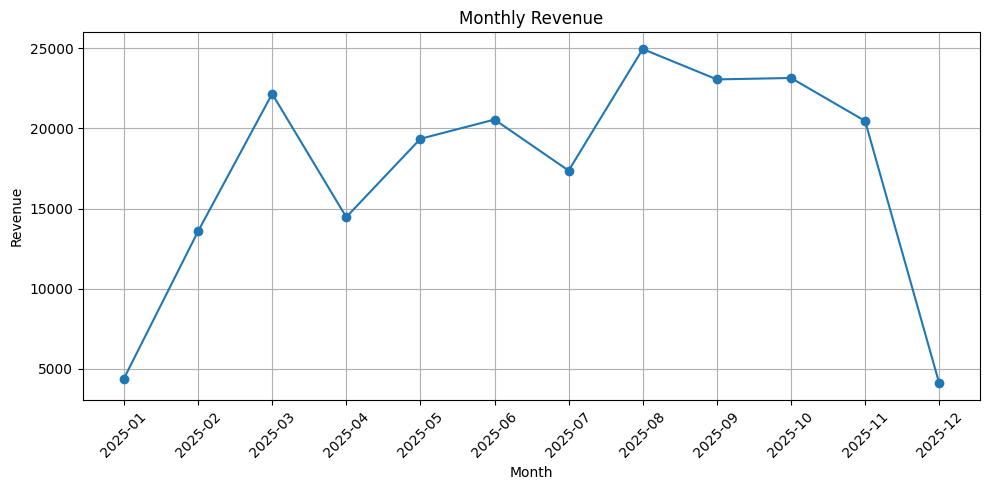

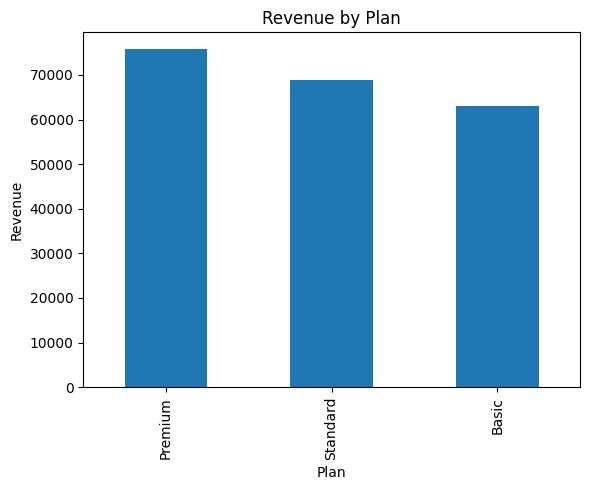

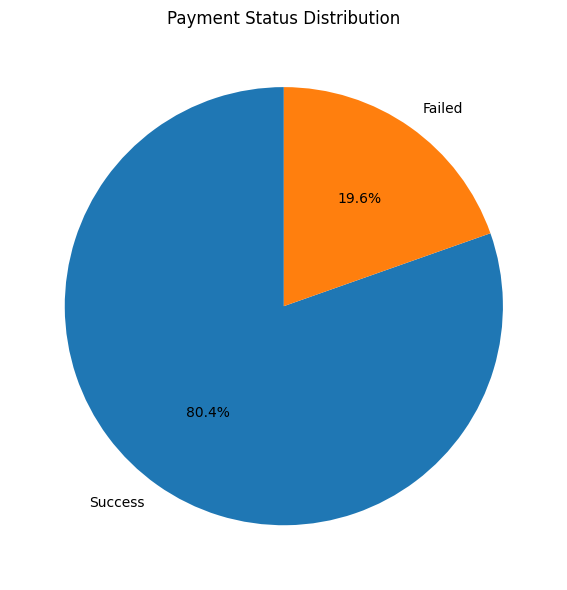

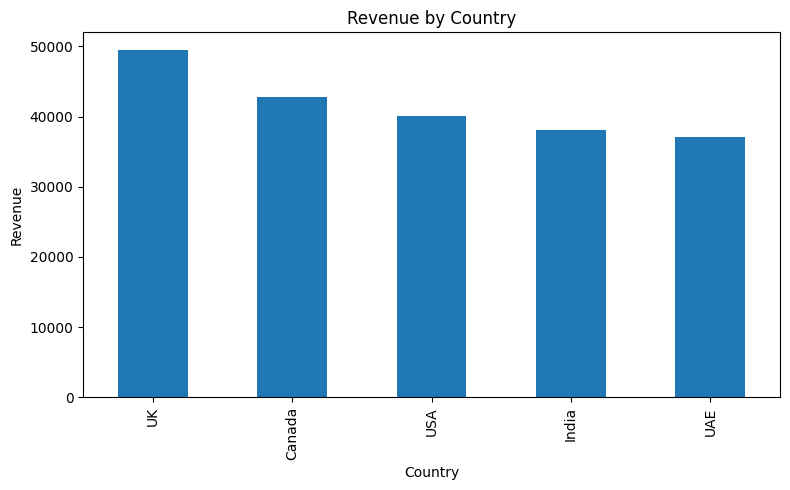


FINAL DASHBOARD KPI
Total Revenue : 207598
Total Users : 164
ARPU : 1265.84
Successful Payments : 402
Failed Payments : 98


In [3]:
# ==========================================
# TASK 9 - PART 3
# Cohort Revenue Analysis & Dashboard Charts
# ==========================================

import matplotlib.pyplot as plt

# Monthly Revenue
monthly_revenue = success_df.groupby(success_df['Payment_Date'].dt.to_period('M'))['Amount'].sum()
monthly_revenue.index = monthly_revenue.index.astype(str)

print("Monthly Revenue")
display(monthly_revenue)

# Cohort Revenue
cohort_revenue = success_df.groupby('Cohort_Month')['Amount'].sum().reset_index()

print("\nCohort Revenue")
display(cohort_revenue)

# -------------------------------
# Chart 1 - Monthly Revenue
# -------------------------------
plt.figure(figsize=(10,5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------
# Chart 2 - Revenue by Plan
# -------------------------------
plt.figure(figsize=(6,5))
plan_revenue.plot(kind='bar')
plt.title("Revenue by Plan")
plt.xlabel("Plan")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# -------------------------------
# Chart 3 - Payment Status
# -------------------------------
plt.figure(figsize=(6,6))
df['Payment_Status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.ylabel("")
plt.title("Payment Status Distribution")
plt.tight_layout()
plt.show()

# -------------------------------
# Chart 4 - Revenue by Country
# -------------------------------
plt.figure(figsize=(8,5))
country_revenue.plot(kind='bar')
plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# -------------------------------
# Dashboard KPIs
# -------------------------------
print("\n==============================")
print("FINAL DASHBOARD KPI")
print("==============================")
print("Total Revenue :", total_revenue)
print("Total Users :", total_users)
print("ARPU :", round(arpu,2))
print("Successful Payments :", len(success_df))
print("Failed Payments :", len(df[df['Payment_Status']=='Failed']))
print("==============================")

In [4]:
# ==========================================
# TASK 9 - PART 4
# Save Files & Generate Summary Report
# ==========================================

# Save Cleaned Dataset
success_df.to_csv("Cleaned_Payment_Data.csv", index=False)

# Save Monthly Revenue
monthly_revenue_df = monthly_revenue.reset_index()
monthly_revenue_df.columns = ["Month", "Revenue"]
monthly_revenue_df.to_csv("Monthly_Revenue.csv", index=False)

# Save Cohort Revenue
cohort_revenue.to_csv("Cohort_Revenue.csv", index=False)

print("Files Saved Successfully!")

# ==========================
# Project Summary
# ==========================

print("\n====================================")
print("        PROJECT SUMMARY")
print("====================================")

print(f"Total Revenue        : {total_revenue}")
print(f"Total Users          : {total_users}")
print(f"ARPU                 : {round(arpu,2)}")
print(f"Successful Payments  : {len(success_df)}")
print(f"Failed Payments      : {len(df[df['Payment_Status']=='Failed'])}")

success_rate = (len(success_df) / len(df)) * 100
failure_rate = (len(df[df['Payment_Status']=='Failed']) / len(df)) * 100

print(f"Success Rate (%)     : {round(success_rate,2)}")
print(f"Failure Rate (%)     : {round(failure_rate,2)}")

print("====================================")

# Top 5 Revenue Countries
print("\nTop 5 Countries by Revenue")
display(country_revenue.head())

# Top Plans
print("\nRevenue by Plan")
display(plan_revenue)

# Save Summary Report
summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Users",
        "ARPU",
        "Successful Payments",
        "Failed Payments",
        "Success Rate",
        "Failure Rate"
    ],
    "Value": [
        total_revenue,
        total_users,
        round(arpu,2),
        len(success_df),
        len(df[df['Payment_Status']=='Failed']),
        round(success_rate,2),
        round(failure_rate,2)
    ]
})

summary.to_csv("Project_Summary.csv", index=False)

print("\nProject_Summary.csv Saved Successfully")
print("\nProject Completed Successfully!")

Files Saved Successfully!

        PROJECT SUMMARY
Total Revenue        : 207598
Total Users          : 164
ARPU                 : 1265.84
Successful Payments  : 402
Failed Payments      : 98
Success Rate (%)     : 80.4
Failure Rate (%)     : 19.6

Top 5 Countries by Revenue


,Amount
Country,
UK,49508
Canada,42817
USA,40023
India,38121
UAE,37129



Revenue by Plan


,Amount
Plan,
Premium,75761
Standard,68763
Basic,63074



Project_Summary.csv Saved Successfully

Project Completed Successfully!


In [5]:
# ==========================================
# TASK 9 - PART 5
# Streamlit Dashboard (app.py)
# ==========================================

app_code = '''
import streamlit as st
import pandas as pd

st.set_page_config(page_title="ARPU & Cohort Revenue Dashboard", layout="wide")

st.title("📊 ARPU & Cohort Revenue Dashboard")
st.write("Task 9 - Failure Handling & Resilience")

df = pd.read_csv("Cleaned_Payment_Data.csv")

total_revenue = df["Amount"].sum()
total_users = df["User_ID"].nunique()
arpu = total_revenue / total_users

success = len(df[df["Payment_Status"]=="Success"])
failed = len(df[df["Payment_Status"]=="Failed"])

col1,col2,col3,col4 = st.columns(4)

col1.metric("Total Revenue", f"₹{total_revenue:,.0f}")
col2.metric("Total Users", total_users)
col3.metric("ARPU", f"₹{arpu:.2f}")
col4.metric("Failed Payments", failed)

st.subheader("Revenue by Plan")
plan = df.groupby("Plan")["Amount"].sum()
st.bar_chart(plan)

st.subheader("Revenue by Country")
country = df.groupby("Country")["Amount"].sum()
st.bar_chart(country)

st.subheader("Monthly Revenue")
df["Payment_Date"] = pd.to_datetime(df["Payment_Date"])
monthly = df.groupby(df["Payment_Date"].dt.to_period("M"))["Amount"].sum()
monthly.index = monthly.index.astype(str)
st.line_chart(monthly)

st.subheader("Dataset Preview")
st.dataframe(df)

st.success("Dashboard Created Successfully")
'''

with open("app.py","w") as f:
    f.write(app_code)

print("app.py Created Successfully")

# requirements.txt
requirements = """
streamlit
pandas
matplotlib
openpyxl
numpy
"""

with open("requirements.txt","w") as f:
    f.write(requirements)

print("requirements.txt Created Successfully")

# README.md
readme = """
# Task 9 - ARPU & Cohort Revenue Dashboard

## Tools Used
- Python
- Pandas
- Streamlit
- Matplotlib
- Google Colab

## KPIs
- Total Revenue
- Total Users
- ARPU
- Payment Success
- Payment Failure
- Revenue by Plan
- Revenue by Country
- Monthly Revenue

Developed for Data Analyst Internship Project.
"""

with open("README.md","w") as f:
    f.write(readme)

print("README.md Created Successfully")

print("\nProject Files Ready for GitHub Upload.")

app.py Created Successfully
requirements.txt Created Successfully
README.md Created Successfully

Project Files Ready for GitHub Upload.
